<div style="background-color:#2E6F9E;
padding:20px;
border-radius:10px;
text-align:center;">

<h1 style="color:white;">
Customer Churn Analysis
</h1>

</div>

## Introduction to Customer Churn Analysis

Customer Churn Analysis is a data analytics project used to identify customers who are likely to stop using a company's products or services. The project analyzes customer information, usage patterns, service details, and billing information to understand why customers leave and which factors are associated with churn.

The main goal is to identify churn patterns, find important factors affecting customer retention, and provide business insights that can help the company reduce customer loss.
This project uses Python libraries such as Pandas, NumPy, Matplotlib, Seaborn,
and Plotly for data analysis and visualization.

## Data Source

The dataset used in this project was collected from Kaggle, an online platform that provides datasets for data science and analytics projects.

The original dataset is the "Customer Churn Analysis", which contains  customer information, payment details, contract Details, and Customer Churn Details.

The dataset was downloaded directly from Kaggle and used for exploratory data analysis, business insights generation, and dashboard development.

## Attribute

| Column  | Description |
|----------|-------------|
|customerID |Unique identification number
|gender     |Gender of the customer
|tenure     |Number of months the customer has stayed with the company
|InternetService	|Type of internet service used by the customer
Contract |	Customer's contract type
PaperlessBilling	|Whether the customer uses paperless billing
MonthlyCharges	|Monthly amount charged to the customer
PaymentMethod	|Method used by the customer to make payments
TotalCharges	|Total amount charged to the customer
Churn	|Indicates whether the customer left the company — Yes/No
Tenure Group	|Customer tenure category such as New or Established



In [1222]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

<div style="
background-color:#dfe3ee;
padding:20px;
border-radius:10px;
text-align:center;">

<h1 style="color:#2E6FDF;">
Data Loading and Initial Overview
</h1>

</div>

## Importing Required Libraries

Imported Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Plotly for data manipulation, analysis, and visualization.

In [1223]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

## Dataset Loading for Further Analysis

The Customer Churn dataset is loaded into a Pandas DataFrame for further exploration and analysis.

In [1224]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\padma\OneDrive\Desktop\DA python
['.vscode', '02 Customer Churn-Dataset.1.csv', '21 - Introduction_Web Scraping (3).ipynb', '22- BeautifulSoup.ipynb', 'adfg.ipynb', 'array.ipynb', 'assignment.py', 'assignments2..ipynb', 'beautiful soup.ipynb', 'Cafe_sales.csv', 'cafe_sales.ipynb', 'conditional statement .py', 'Customer Churn Project.ipynb', 'customers_dataset.csv', 'dictionary.py', 'file.html', 'Final .project.ipynb', 'Final project.ipynb', 'Final.. project.ipynb', 'food_orders_dataset.csv', 'for loop.py', 'Functional.py', 'Global_Superstore2.csv', 'html.retrive.ipynb', 'Html_retrival2_.ipynb', 'htm_retrival.ipynb', 'list.py', 'looping statement.py', 'numpy.ipynb', 'operators.py', 'orders.csv', 'orders.ipynb', 'padma.py', 'padmaja.ipynb', 'Pandas 2.ipynb', 'pandas.ipynb', 'pandas2.ipynb', 'pappy.py', 'pm.py', 'pp.py', 'Project Churn.ipynb', 'Python_intro.py', 'quotes.csv', 'rock paper scissor.py', 'selenium.ipynb', 'set.py', 'string.py', 'tuple.py', 'types of arguments.py', 'v

 # Data Extraction

Data extraction is the process of importing the dataset into the Python environment for analysis.

The Customer Churn dataset was loaded using the Pandas library. After loading, the dataset was inspected to understand its structure, dimensions, and data types.

In [1225]:
import pandas as pd
df = pd.read_csv('02 Customer Churn-Dataset.1.csv', encoding='latin1')
df.head()

,customerID,gender,tenure,InternetService,Contract,PaperlessBilling,MonthlyCharges,PaymentMethod,TotalCharges,Churn,Tenure Group
0,7590-VHVEG,Female,1,Dsl,Month-To-Month,Yes,30,Electronic Check,30.0,No,New
1,5575-GNVDE,Male,34,Dsl,One Year,No,57,Mailed Check,1890.0,No,Extablished
2,3668-QPYBK,Male,2,Dsl,Month-To-Month,Yes,54,Mailed Check,108.0,Yes,New
3,7795-CFOCW,Male,45,Dsl,One Year,No,42,Bank Transfer (Automatic),1841.0,No,Extablished
4,9237-HQITU,Female,2,Fiber Optic,Month-To-Month,Yes,71,Electronic Check,152.0,Yes,New


In [1226]:
#Displaying the Dimensions of the Dataset
print("Number of Rows:",df.shape[0])
print("Number of Columns:",df.shape[1])

Number of Rows: 7043
Number of Columns: 11


In [1227]:
#Displaying the First 5 Rows
df.head()

,customerID,gender,tenure,InternetService,Contract,PaperlessBilling,MonthlyCharges,PaymentMethod,TotalCharges,Churn,Tenure Group
0,7590-VHVEG,Female,1,Dsl,Month-To-Month,Yes,30,Electronic Check,30.0,No,New
1,5575-GNVDE,Male,34,Dsl,One Year,No,57,Mailed Check,1890.0,No,Extablished
2,3668-QPYBK,Male,2,Dsl,Month-To-Month,Yes,54,Mailed Check,108.0,Yes,New
3,7795-CFOCW,Male,45,Dsl,One Year,No,42,Bank Transfer (Automatic),1841.0,No,Extablished
4,9237-HQITU,Female,2,Fiber Optic,Month-To-Month,Yes,71,Electronic Check,152.0,Yes,New


In [1228]:
#Checking DataFrame Structural Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   tenure            7043 non-null   int64  
 3   InternetService   7043 non-null   object 
 4   Contract          7043 non-null   object 
 5   PaperlessBilling  7043 non-null   object 
 6   MonthlyCharges    7043 non-null   int64  
 7   PaymentMethod     7043 non-null   object 
 8   TotalCharges      7032 non-null   float64
 9   Churn             7043 non-null   object 
 10  Tenure Group      7043 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 605.4+ KB


## Statistical Summary

The describe() function generates statistical measures for numerical columns including mean, median, minimum, maximum, and standard deviation.

In [1229]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.758768,2283.294653
std,24.559481,30.091650,2266.769670
min,0.000000,18.000000,19.000000
25%,9.000000,36.000000,401.750000
50%,29.000000,70.000000,1397.500000
75%,55.000000,90.000000,3794.250000
max,72.000000,119.000000,8685.000000


<div style="
background-color:#dfe3ee;
padding:20px;
border-radius:10px;
text-align:center;">

<h1 style="color:#2E6FDF;">
Data Cleaning and Preprocessing
</h1>

</div>

# Data Cleaning

Data cleaning is an important step in data analysis. It involves identifying and handling missing values, duplicate records, incorrect data types, and inconsistencies in the dataset to improve data quality and ensure accurate analysis.

In [1230]:
#Checking Missing Values
df.isnull().sum()

customerID           0
gender               0
tenure               0
InternetService      0
Contract             0
PaperlessBilling     0
MonthlyCharges       0
PaymentMethod        0
TotalCharges        11
Churn                0
Tenure Group         0
dtype: int64

In [1231]:
df.duplicated().sum()

np.int64(0)

In [1232]:
df.drop_duplicates(inplace=True)

In [1233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   tenure            7043 non-null   int64  
 3   InternetService   7043 non-null   object 
 4   Contract          7043 non-null   object 
 5   PaperlessBilling  7043 non-null   object 
 6   MonthlyCharges    7043 non-null   int64  
 7   PaymentMethod     7043 non-null   object 
 8   TotalCharges      7032 non-null   float64
 9   Churn             7043 non-null   object 
 10  Tenure Group      7043 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 605.4+ KB


In [1234]:
df.dtypes

customerID           object
gender               object
tenure                int64
InternetService      object
Contract             object
PaperlessBilling     object
MonthlyCharges        int64
PaymentMethod        object
TotalCharges        float64
Churn                object
Tenure Group         object
dtype: object

##Standardize Column Name

Column names were standardized to maintain consistency and improve readability during analysis.

In [1235]:
df.columns = (
df.columns
.str.lower()
.str.strip()
.str.replace(' ','_')
)

df.columns

Index(['customerid', 'gender', 'tenure', 'internetservice', 'contract',
       'paperlessbilling', 'monthlycharges', 'paymentmethod', 'totalcharges',
       'churn', 'tenure_group'],
      dtype='object')

## Exploratory Data Analysis
### A. Univariate analysis
Study individual variables.

### Churn Distribution

In [1236]:
df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

### Tenure Distribution

In [1237]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

### Contract Distribution

In [1238]:
df['contract'].value_counts()

contract
Month-To-Month    3875
Two Year          1695
One Year          1473
Name: count, dtype: int64

# Bivariate analysis


### Churn by Contract

In [1239]:
pd.crosstab(df['contract'], df['churn'], normalize='index') * 100

churn,No,Yes
contract,,
Month-To-Month,57.290323,42.709677
One Year,88.730482,11.269518
Two Year,97.168142,2.831858


### Churn by Tenure Group

In [1240]:
pd.crosstab(df['tenure_group'], df['churn'], normalize='index') * 100

churn,No,Yes
tenure_group,,
Early,71.289062,28.710938
Extablished,79.611041,20.388959
Loyal,90.486824,9.513176
New,52.561757,47.438243


### Churn by Internet Service

In [1241]:
pd.crosstab(df['internetservice'], df['churn'], normalize='index') * 100

churn,No,Yes
internetservice,,
Dsl,81.040892,18.959108
Fiber Optic,58.107235,41.892765
No,92.595020,7.404980


### Churn by Payment Method

In [1242]:
pd.crosstab(df['paymentmethod'], df['churn'], normalize='index') * 100

churn,No,Yes
paymentmethod,,
Bank Transfer (Automatic),83.290155,16.709845
Credit Card (Automatic),84.756899,15.243101
Electronic Check,54.714588,45.285412
Mailed Check,80.893300,19.106700


<div style="
background-color:#E8F8E8;
padding:20px;
border-radius:10px;
text-align:center;">

<h3 style="color:green;">

✓ EDA was successfully performed to understand the dataset.

</h3>

</div>

<div style="
background-color:#EAF2FF;
padding:20px;
border-radius:10px;
text-align:center;">

<h1 style="color:#2E6FDD;">
Data Visualizations 
</h1>

</div>

### Data Visualization
Data visualization is the process of representing data using charts, graphs, and plots to identify patterns, trends, relationships, and key insights.

### Churn vs Monthly Charges

Compare:

Churned customers

Non-churned customers

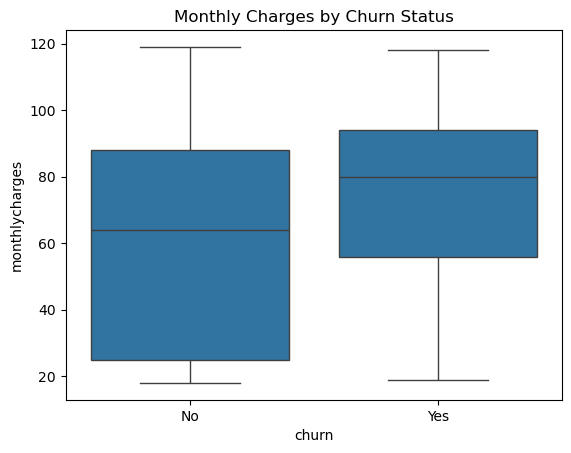

In [1243]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='churn', y='monthlycharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.show()

### Churn vs Tenure

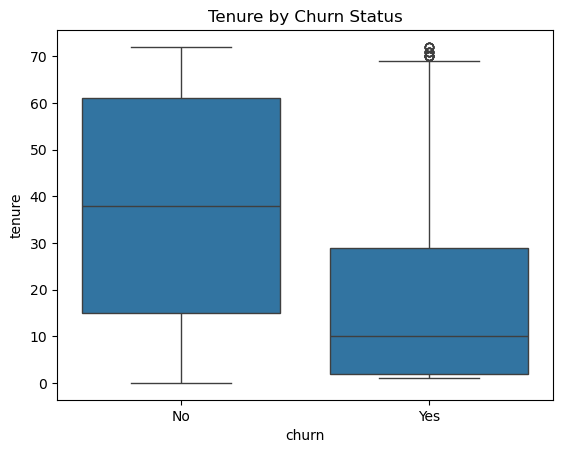

In [1244]:
sns.boxplot(x='churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')
plt.show()

### Churn Rate Analysis

In [1245]:
churn_rate = df['churn'].value_counts(normalize=True) * 100
churn_rate

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

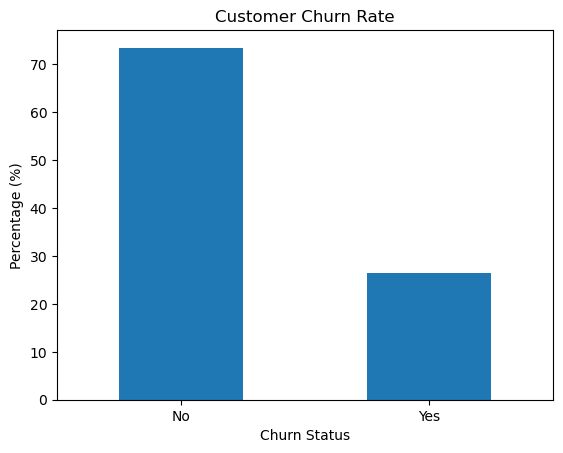

In [1246]:
import matplotlib.pyplot as plt

churn_rate.plot(kind='bar')

plt.title('Customer Churn Rate')
plt.xlabel('Churn Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

### Churn by Contract

In [1247]:
contract_churn = pd.crosstab(
    df['contract'],
    df['churn'],
    normalize='index'
) * 100

contract_churn

churn,No,Yes
contract,,
Month-To-Month,57.290323,42.709677
One Year,88.730482,11.269518
Two Year,97.168142,2.831858


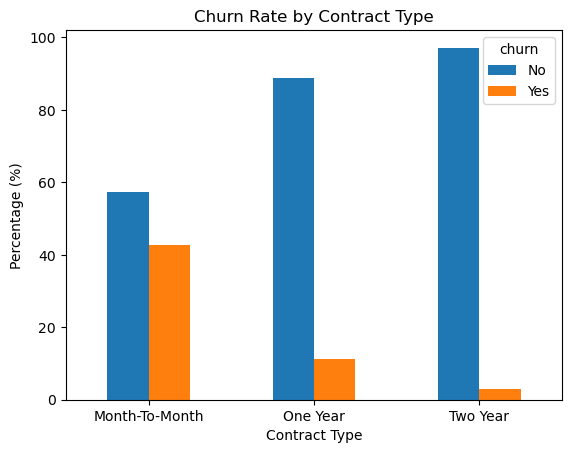

In [1248]:
contract_churn.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

### Churn by Internet Service

In [1249]:
internet_churn = pd.crosstab(
    df['internetservice'],
    df['churn'],
    normalize='index'
) * 100

internet_churn

churn,No,Yes
internetservice,,
Dsl,81.040892,18.959108
Fiber Optic,58.107235,41.892765
No,92.595020,7.404980


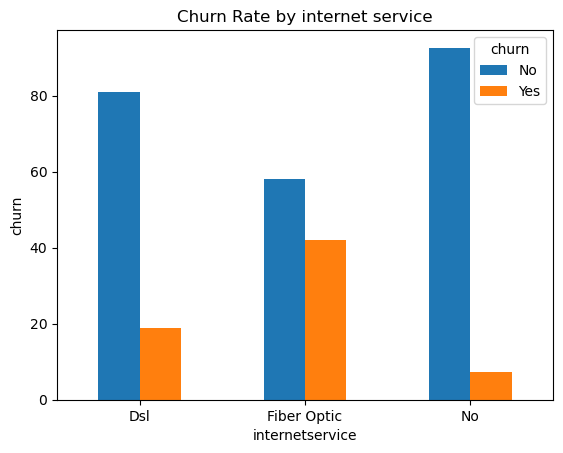

In [1250]:
internet_churn.plot(kind='bar')

plt.title('Churn Rate by internet service')
plt.xlabel('internetservice')
plt.ylabel('churn')
plt.xticks(rotation=0)
plt.show()

### Churn by Payment Method

In [1251]:
payment_churn = pd.crosstab(
    df['paymentmethod'],
    df['churn'],
    normalize='index'
) * 100

payment_churn

churn,No,Yes
paymentmethod,,
Bank Transfer (Automatic),83.290155,16.709845
Credit Card (Automatic),84.756899,15.243101
Electronic Check,54.714588,45.285412
Mailed Check,80.893300,19.106700


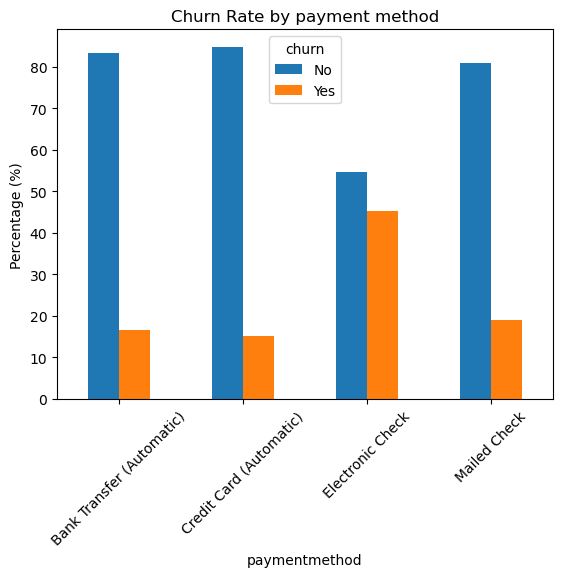

In [1252]:
payment_churn.plot(kind='bar')

plt.title('Churn Rate by payment method')
plt.xlabel('paymentmethod')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

### Churn by Gender

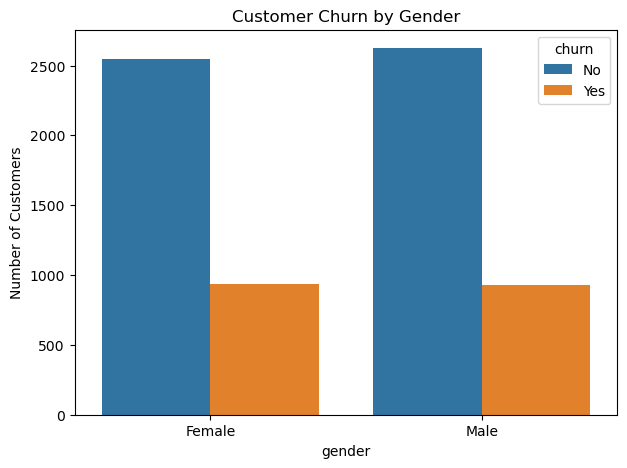

In [1253]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='gender', hue='churn')

plt.title('Customer Churn by Gender')
plt.xlabel('gender')
plt.ylabel('Number of Customers')
plt.show()

### Churn by Paperless Billing

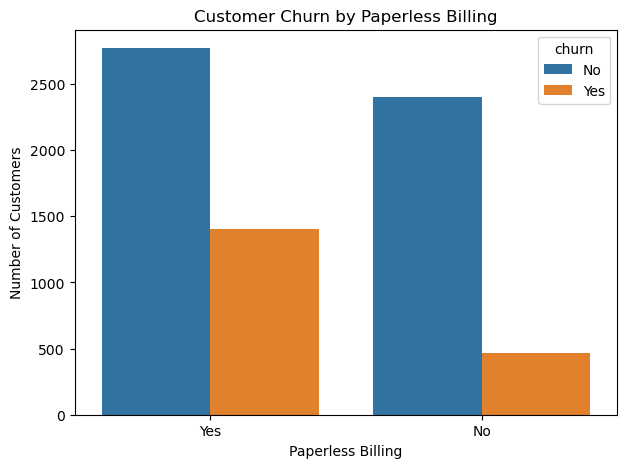

In [1254]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='paperlessbilling', hue='churn')

plt.title('Customer Churn by Paperless Billing')
plt.xlabel('Paperless Billing')
plt.ylabel('Number of Customers')
plt.show()

### Average Monthly Charges by Tenure Group

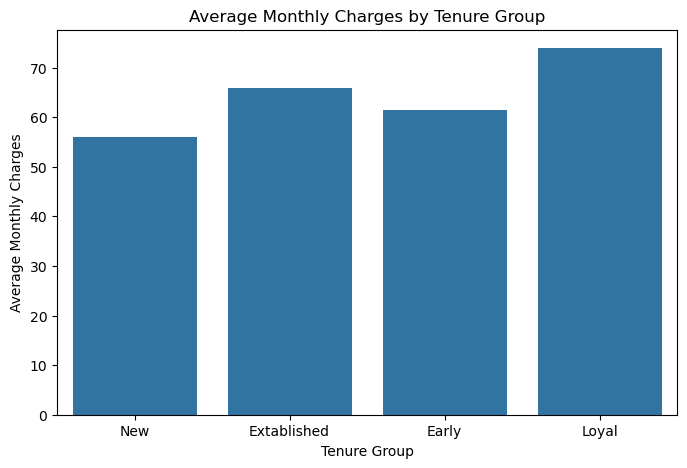

In [1255]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='tenure_group', y='monthlycharges', errorbar=None)

plt.title('Average Monthly Charges by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Average Monthly Charges')
plt.show()

### Identify high-risk customers

In [1256]:
df['Risk_Level'] = 'Low'

df.loc[
    (df['tenure'] <= 12) & (df['monthlycharges'] >= 70),
    'Risk_Level'
] = 'High'

df['Risk_Level'].value_counts()

Risk_Level
Low     6106
High     937
Name: count, dtype: int64

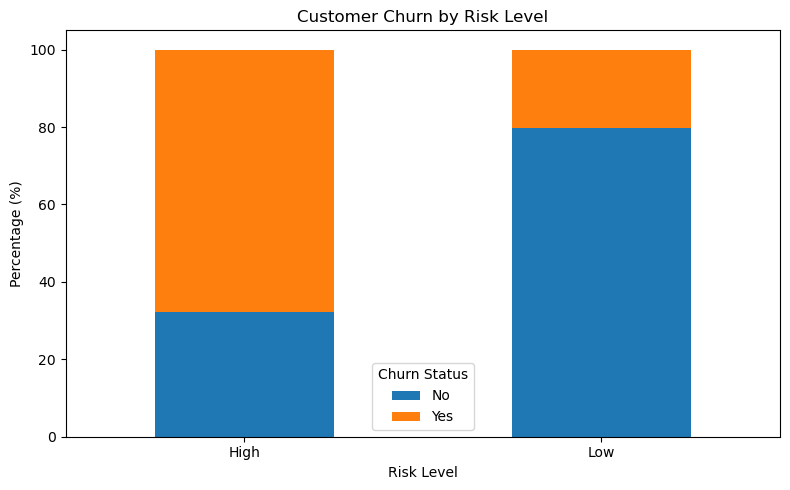

In [1257]:
risk_churn = pd.crosstab(
    df['Risk_Level'],
    df['churn'],
    normalize='index'
) * 100

risk_churn = risk_churn.reset_index()

risk_churn.plot(
    x='Risk_Level',
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Customer Churn by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn Status')
plt.tight_layout()
plt.show()

### Tenure Distribution by Churn

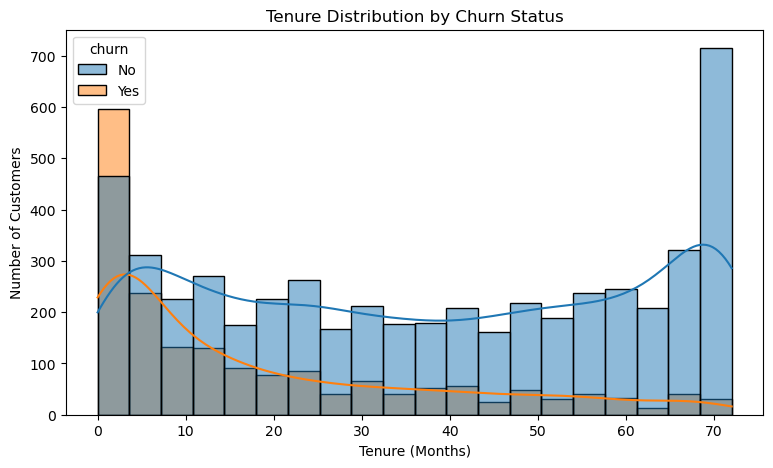

In [1258]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x='tenure', hue='churn', bins=20, kde=True)

plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

### Correlation matrix

In [1259]:
# Select numerical columns
num_cols = ['tenure', 'monthlycharges', 'totalcharges']

# Correlation matrix
correlation = df[num_cols].corr()

correlation

,tenure,monthlycharges,totalcharges
tenure,1.000000,0.247853,0.825880
monthlycharges,0.247853,1.000000,0.651004
totalcharges,0.825880,0.651004,1.000000


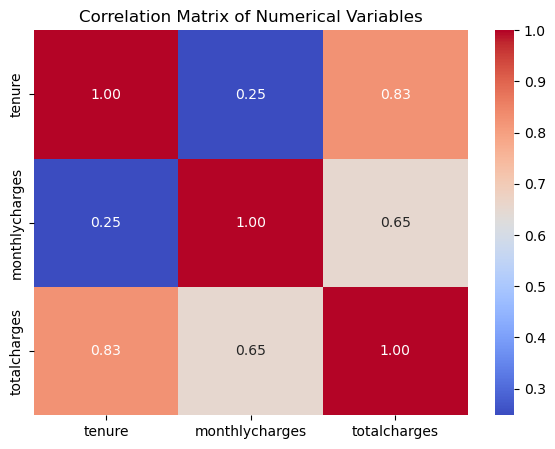

In [1260]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Calculate estimated customer lifetime value

In [1261]:
df[['tenure', 'monthlycharges', 'totalcharges', 'churn']].head()

,tenure,monthlycharges,totalcharges,churn
0,1,30,30.0,No
1,34,57,1890.0,No
2,2,54,108.0,Yes
3,45,42,1841.0,No
4,2,71,152.0,Yes


### Compare average Total Charges between Churned and Retained customers

In [1262]:
clv_analysis = df.groupby('churn')['totalcharges'].agg(
    ['count', 'mean', 'median', 'sum']
).round(2)

clv_analysis

,count,mean,median,sum
churn,,,,
No,5163,2555.34,1684.0,13193201.0
Yes,1869,1531.80,704.0,2862927.0


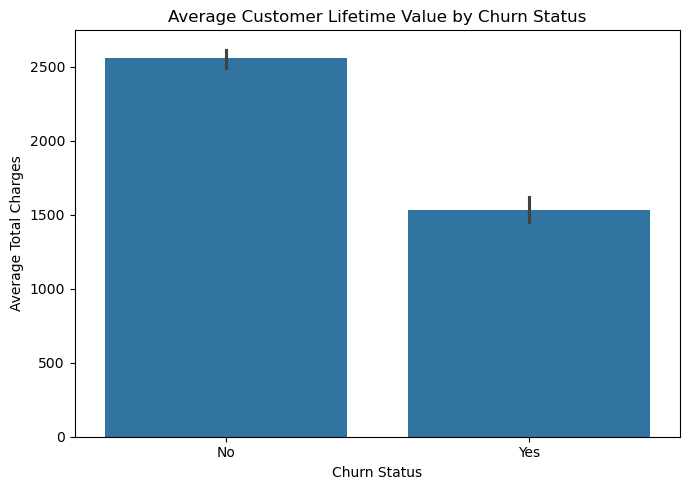

In [1263]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='churn',
    y='totalcharges',
    estimator='mean'
)

plt.title('Average Customer Lifetime Value by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Average Total Charges')
plt.tight_layout()
plt.show()

<div style ="
    border-left: 6px solid #2ecc71;
    background-color: #f4fff8;
    padding: 12px 16px;
    margin: 10px 0;
    font-size: 15px;
    color: #2c3e50;
">
<strong>✔ Visualizations Completed:</strong>
Visualizations were successfully created
</div>

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Insight Generation and Report
</h2>

### Key Findings – Customer Churn Analysis

##### 1  Customer churn is a significant business concern, with a considerable portion of customers leaving the service.
##### 2  Contract type has a strong relationship with churn, with customers on shorter-term contracts generally showing greater churn risk than customers with longer-term contracts.
##### 3  Newer customers are more vulnerable to churn, indicating that the early customer lifecycle is important for retention.
##### 4  Higher monthly charges are associated with increased churn risk, suggesting that pricing or perceived value may influence customer decisions.
##### 5  Payment method shows differences in churn behavior, making payment preference an important factor to   monitor.
##### 6  Internet service type influences churn patterns, with some service categories showing higher customer loss than others.
##### 7  High-risk customer segments can be identified by combining factors such as shorter tenure and higher monthly charges.
##### 8  Tenure, Monthly Charges, and Total Charges show relationships that help explain differences in customer behavior.

### Final Project Finding

The analysis shows that customer churn is influenced by multiple factors, particularly contract type, tenure, monthly charges, payment method, and internet service. Identifying high-risk customer segments can help businesses implement targeted retention strategies and reduce customer loss.

### Business Insights – Customer Churn Analysis

* Focus on new customers – Customers with shorter tenure are more likely to churn, so early-stage onboarding and engagement programs should be strengthened.
* Encourage long-term contracts – Customers on shorter contracts show higher churn risk. Offering attractive annual or two-year plans can improve customer retention.
* Review high monthly charges – Customers with higher monthly charges may have greater churn risk. Personalized discounts or better-value packages could help reduce cancellations.
* Target high-risk customers – Combining factors such as low tenure + high monthly charges can help identify customers who need immediate retention attention.
* Improve payment experience – Payment methods with higher churn rates should be investigated to identify possible payment difficulties or customer preferences.
* Improve service experience – If a particular internet-service category has higher churn, the company should investigate service quality, pricing, and customer satisfaction for that segment.
* Use customer segmentation – Instead of applying the same retention strategy to everyone, businesses can create targeted offers based on customer tenure, contract, charges, and service type

Business Impact

The analysis can help the business identify customers at risk of leaving, prioritize retention efforts, improve customer experience, and ultimately reduce churn and protect recurring revenue.

### Conclusion – Customer Churn Analysis

The Customer Churn Analysis provided valuable insights into customer behavior and the factors associated with customer churn. The analysis identified important patterns related to contract type, tenure, monthly charges, payment method, and internet service. By identifying high-risk customer segments, businesses can develop targeted retention strategies, improve customer satisfaction, reduce churn, and protect recurring revenue.

<div style="
background-color:#d4edda;
border:2px solid #28a745;
padding:20px;
border-radius:10px;
text-align:center;">

<h2 style="color:#28a745;">
✓ Project Completed Successfully
</h2>

<p style="color:#155724;">
Customer churn Analysis was successfully completed.
The dataset was cleaned, analyzed, visualized, and business insights were generated.
</p>

</div>